In [1]:
! pip install seaborn
! pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score,classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
import warnings 
warnings.filterwarnings('ignore')


## Read Data

In [3]:
data=pd.read_csv('Breast_Cancer.csv')

In [4]:
data

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive


## EDA

In [5]:
data.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

In [6]:
data.columns=data.columns.str.strip().str.lower().str.replace(' ','_',regex=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     4024 non-null   int64 
 1   race                    4024 non-null   object
 2   marital_status          4024 non-null   object
 3   t_stage                 4024 non-null   object
 4   n_stage                 4024 non-null   object
 5   6th_stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   grade                   4024 non-null   object
 8   a_stage                 4024 non-null   object
 9   tumor_size              4024 non-null   int64 
 10  estrogen_status         4024 non-null   object
 11  progesterone_status     4024 non-null   object
 12  regional_node_examined  4024 non-null   int64 
 13  reginol_node_positive   4024 non-null   int64 
 14  survival_months         4024 non-null   int64 
 15  stat

In [8]:
data.describe()

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [9]:
data.shape

(4024, 16)

In [10]:
data.isna().sum()

age                       0
race                      0
marital_status            0
t_stage                   0
n_stage                   0
6th_stage                 0
differentiate             0
grade                     0
a_stage                   0
tumor_size                0
estrogen_status           0
progesterone_status       0
regional_node_examined    0
reginol_node_positive     0
survival_months           0
status                    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(1)

In [12]:
data.drop_duplicates(inplace=True)

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
cat_cols=data.select_dtypes(include='O').columns

In [15]:
for col in cat_cols:
    print(col)
    print(data[col].nunique())
    print(data[col].unique())
    print('\n','-'*100,'\n')

race
3
['White' 'Black' 'Other']

 ---------------------------------------------------------------------------------------------------- 

marital_status
5
['Married' 'Divorced' 'Single ' 'Widowed' 'Separated']

 ---------------------------------------------------------------------------------------------------- 

t_stage
4
['T1' 'T2' 'T3' 'T4']

 ---------------------------------------------------------------------------------------------------- 

n_stage
3
['N1' 'N2' 'N3']

 ---------------------------------------------------------------------------------------------------- 

6th_stage
5
['IIA' 'IIIA' 'IIIC' 'IIB' 'IIIB']

 ---------------------------------------------------------------------------------------------------- 

differentiate
4
['Poorly differentiated' 'Moderately differentiated' 'Well differentiated'
 'Undifferentiated']

 ---------------------------------------------------------------------------------------------------- 

grade
4
['3' '2' '1' ' anaplastic; Grade IV']



In [16]:
num_cols=data.select_dtypes(include='number').columns

In [17]:
num_cols

Index(['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive',
       'survival_months'],
      dtype='object')

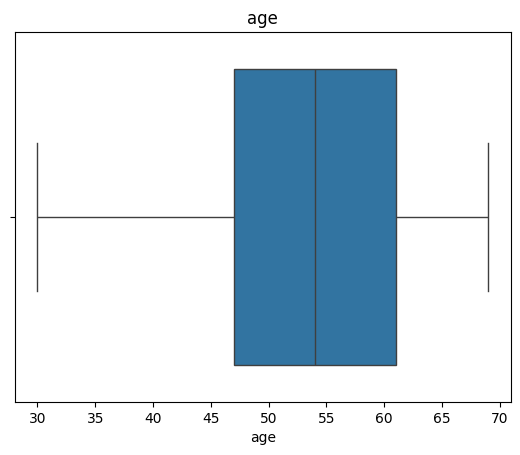

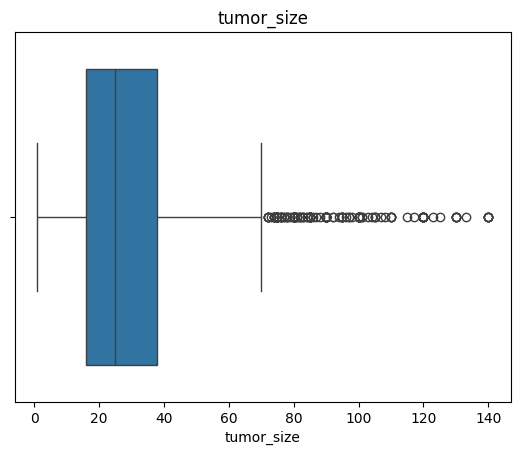

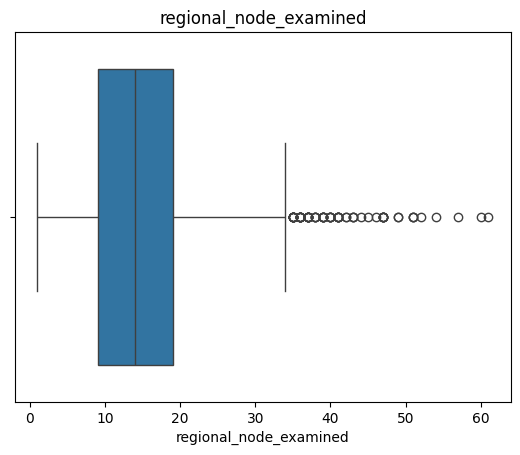

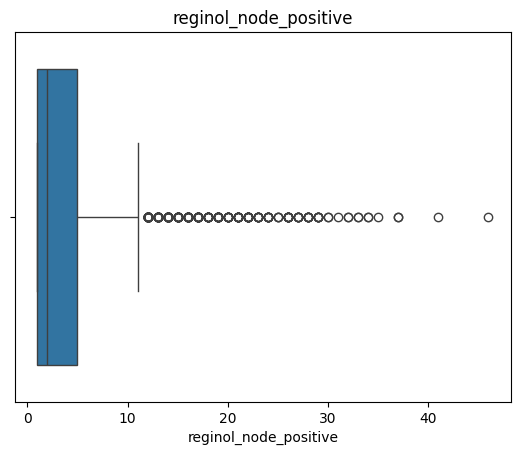

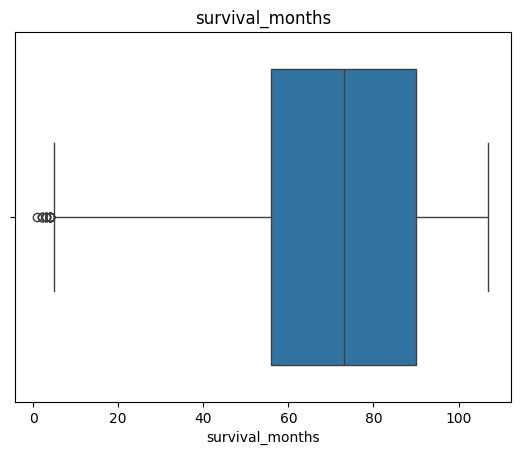

In [18]:
# for col in num_cols:
#     plt.figure()
#     sns.boxplot(data=data, x=col)
#     plt.title(col)
#     plt.show()
for col in num_cols:
    plt.figure()
    sns.boxplot(data=data,x=col)
    plt.title(col)
    plt.show()

In [19]:
num_cols

Index(['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive',
       'survival_months'],
      dtype='object')

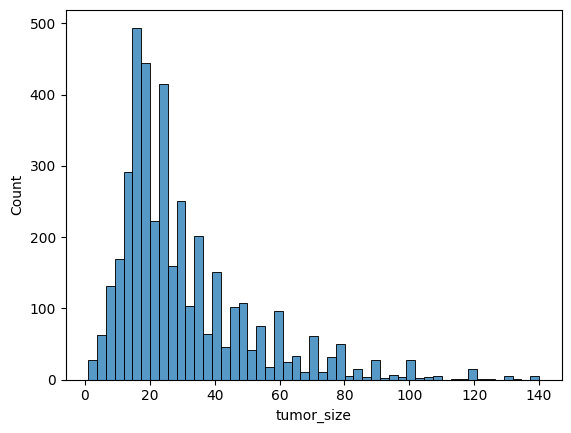

In [20]:
sns.histplot(data['tumor_size'])
plt.show()

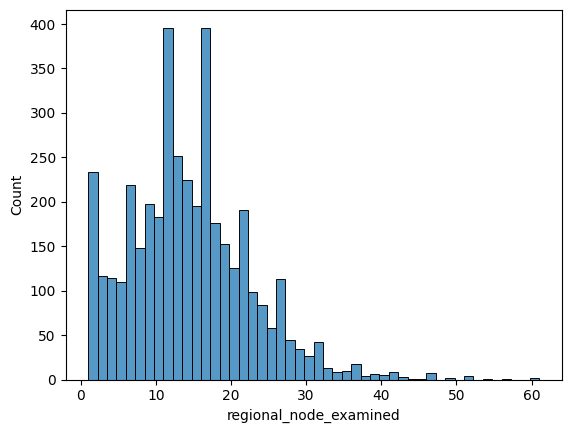

In [21]:
sns.histplot(data['regional_node_examined'])
plt.show()

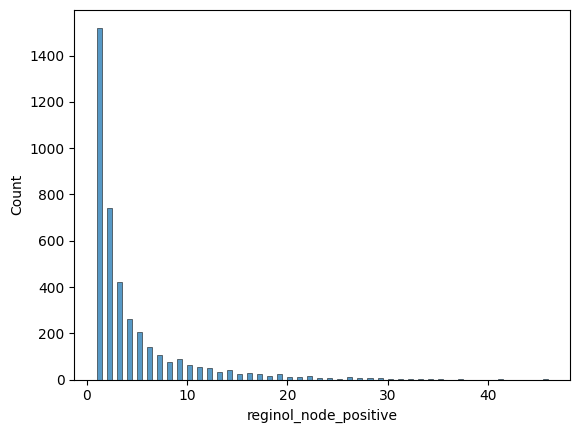

In [22]:
sns.histplot(data['reginol_node_positive'])
plt.show()

<Axes: xlabel='age', ylabel='Count'>

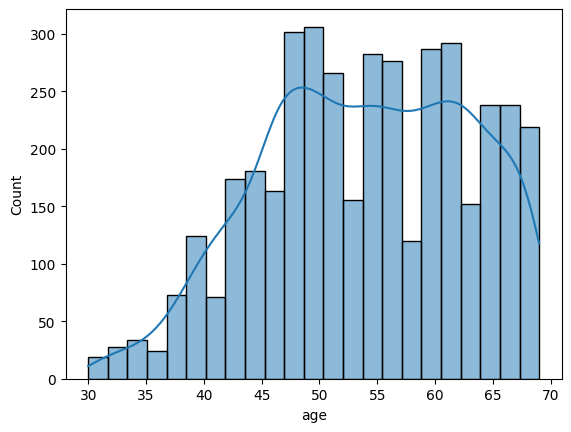

In [23]:
sns.histplot(data['age'],kde=True)

## ِAnalysis

In [24]:
data.columns

Index(['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage',
       'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status',
       'progesterone_status', 'regional_node_examined',
       'reginol_node_positive', 'survival_months', 'status'],
      dtype='object')

In [25]:
data['status'].value_counts()

status
Alive    3407
Dead      616
Name: count, dtype: int64

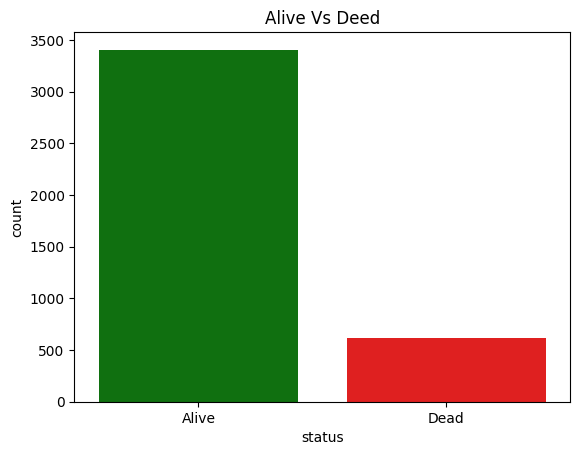

In [26]:
sns.countplot(x='status',data=data,palette=['green','red'])
plt.title('Alive Vs Deed')
plt.show()

In [27]:
data.groupby('status')['survival_months'].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Alive,3407.0,75.946874,19.386293,1.0,61.0,77.0,92.0,107.0
Dead,616.0,45.610390,23.966253,2.0,27.0,44.0,61.0,102.0


In [28]:
data=data.drop('survival_months',axis=1)

## Spilting

In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['status']=le.fit_transform(data['status'])

In [30]:
data

,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,0
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,0
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,0
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,0
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,0
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,0
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,0
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,0


In [31]:
print(le.classes_)

['Alive' 'Dead']


## ALive-> 0 
## Dead -> 1

In [32]:
x= data.drop('status', axis=1)
y= data['status']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
num_cols

Index(['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive',
       'survival_months'],
      dtype='object')

## preprocessing 

In [42]:
from sklearn.preprocessing import StandardScaler, RobustScaler

log_cols = ['tumor_size', 'regional_node_examined', 'reginol_node_positive']

for col in log_cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])


In [43]:
standard_cols = ['tumor_size', 'regional_node_examined', 'age']
standard_scaler = StandardScaler()
x_train[standard_cols] = standard_scaler.fit_transform(x_train[standard_cols])  
x_test[standard_cols]  = standard_scaler.transform(x_test[standard_cols])       

In [45]:
robust_cols = ['reginol_node_positive']
robust_scaler = RobustScaler()
x_train[robust_cols] = robust_scaler.fit_transform(x_train[robust_cols])  
x_test[robust_cols]  = robust_scaler.transform(x_test[robust_cols])        

In [ ]:
# standard_cols = ['tumor_size', 'regional_node_examined', 'age']
# standard_scaler = StandardScaler()
# x_train[standard_cols] = standard_scaler.fit_transform(x_train[standard_cols]) 
# x_test[standard_cols]  = standard_scaler.transform(x_test[standard_cols])  

In [ ]:
# x_train['tumor_size']=np.log1p(x_train['tumor_size'])
# x_test['tumor_size']=np.log1p(x_test['tumor_size'])

In [ ]:
# sns.histplot(x_train['tumor_size'])
# plt.title('tumor_size')
# plt.show()

In [ ]:
# from sklearn.preprocessing import StandardScaler

# # إنشاء StandardScaler
# scaler = StandardScaler()

# # تطبيق StandardScaler على البيانات
# x_train[['tumor_size']] = scaler.fit_transform(x_train[['tumor_size']])
# x_test[['tumor_size']] = scaler.transform(x_test[['tumor_size']])


In [ ]:
# sns.histplot(x_train['tumor_size'])
# plt.title('tumor_size after StandardScaler')
# plt.show()

In [ ]:
# x_train['regional_node_examined'] = np.log1p(x_train['regional_node_examined'])
# x_test['regional_node_examined'] = np.log1p(x_test['regional_node_examined'])

In [ ]:
# sns.histplot(x='regional_node_examined',data=x_train)
# plt.title('regional_node_examined')
# plt.show()

In [ ]:
# standard_scaler = StandardScaler()

# x_train[['regional_node_examined']] = standard_scaler.fit_transform(
#     x_train[['regional_node_examined']]
# )

# x_test[['regional_node_examined']] = standard_scaler.transform(
#     x_test[['regional_node_examined']]
# )

In [ ]:
# sns.histplot(x='regional_node_examined',data=x_train,kde=True)
# plt.title('regional_node_examined after StandardScaler')
# plt.show()

In [ ]:
# x_train['reginol_node_positive'] = np.log1p(x_train['reginol_node_positive'])
# x_test['reginol_node_positive'] = np.log1p(x_test['reginol_node_positive'])

In [ ]:
# sns.histplot(x_train['reginol_node_positive'],kde=True)
# plt.title('reginol_node_positive')
# plt.show()

In [ ]:
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()
# x_train['reginol_node_positive'] = scaler.fit_transform(x_train[['reginol_node_positive']])
# x_test['reginol_node_positive'] = scaler.transform(x_test[['reginol_node_positive']])

In [ ]:
# sns.histplot(x_train['reginol_node_positive'], kde=True)
# plt.title('reginol_node_positive after RobustScaler')
# plt.show()

## Encoding

In [46]:
x_train.columns

Index(['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage',
       'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status',
       'progesterone_status', 'regional_node_examined',
       'reginol_node_positive'],
      dtype='object')

In [47]:
print(x_train.columns)

Index(['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage',
       'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status',
       'progesterone_status', 'regional_node_examined',
       'reginol_node_positive'],
      dtype='object')


## ordinal Encoding 

In [48]:
t_stage_map = {'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4}
x_train['t_stage'] = x_train['t_stage'].map(t_stage_map)
x_test['t_stage']  = x_test['t_stage'].map(t_stage_map)

In [49]:
x_train['t_stage'].head()

479     2
3693    2
2399    2
1561    2
2684    3
Name: t_stage, dtype: int64

In [50]:
x_train['t_stage'].isna().sum(), x_test['t_stage'].isna().sum()


(np.int64(0), np.int64(0))

In [51]:
n_stage_map = {'N1': 1, 'N2': 2, 'N3': 3}
x_train['n_stage']=x_train['n_stage'].map(n_stage_map)
x_test['n_stage']=x_test['n_stage'].map(n_stage_map)

In [52]:
x_train['n_stage'].isna().sum(), x_test['n_stage'].isna().sum()


(np.int64(0), np.int64(0))

In [53]:
sixth_stage_map = {
    'IIA': 1,
    'IIB': 2,
    'IIIA': 3,
    'IIIB': 4,
    'IIIC': 5
}
x_train['6th_stage'] = x_train['6th_stage'].map(sixth_stage_map)
x_test['6th_stage']  = x_test['6th_stage'].map(sixth_stage_map)

In [54]:
x_train['6th_stage'].isna().sum(),x_test['6th_stage'].isna().sum()

(np.int64(0), np.int64(0))

In [55]:
differentiate_map = {
    'Undifferentiated': 1,
    'Poorly differentiated': 2,
    'Moderately differentiated': 3,
    'Well differentiated': 4
}

x_train['differentiate'] = x_train['differentiate'].map(differentiate_map)
x_test['differentiate']  = x_test['differentiate'].map(differentiate_map)

In [56]:
x_train['differentiate'].isna().sum(),x_test['differentiate'].isna().sum()

(np.int64(0), np.int64(0))

In [57]:
grade_map = {
    '1': 1,
    '2': 2,
    '3': 3,
    ' anaplastic; Grade IV': 4
}

x_train['grade'] = x_train['grade'].map(grade_map)
x_test['grade']  = x_test['grade'].map(grade_map)


In [58]:
x_train['grade'].isna().sum(),x_test['grade'].isna().sum()

(np.int64(0), np.int64(0))

## OHE

In [59]:
from sklearn.preprocessing import OneHotEncoder
one_hot_cols = ['race', 'marital_status']
ohe=OneHotEncoder(drop='first',sparse_output=False)
ohe_train_arr=ohe.fit_transform(x_train[one_hot_cols])
ohe_train_df=pd.DataFrame(
    ohe_train_arr,columns=ohe.get_feature_names_out(one_hot_cols),index=x_train.index
)
ohe_test_arr=ohe.transform(x_test[one_hot_cols])
ohe_test_df=pd.DataFrame(ohe_test_arr,columns=ohe.get_feature_names_out(one_hot_cols),
                        index=x_test.index)
x_train = pd.concat([x_train.drop(columns=one_hot_cols), ohe_train_df], axis=1)
x_test  = pd.concat([x_test.drop(columns=one_hot_cols), ohe_test_df], axis=1)

## Binary columns

In [60]:
# a_stage
a_stage_map={'Regional':0,'Distant':1}
x_train['a_stage']=x_train['a_stage'].map(a_stage_map)
x_test['a_stage']=x_test['a_stage'].map(a_stage_map)


In [61]:
# estrogen_status
hormone_map={'Negative':0,'Positive':1}
x_train['estrogen_status']=x_train['estrogen_status'].map(hormone_map)
x_test['estrogen_status']=x_test['estrogen_status'].map(hormone_map)

In [62]:
# progesterone_status
x_train['progesterone_status']=x_train['progesterone_status'].map(hormone_map)
x_test['progesterone_status']=x_test['progesterone_status'].map(hormone_map)

In [63]:
x_train

,age,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,race_Other,race_White,marital_status_Married,marital_status_Separated,marital_status_Single,marital_status_Widowed
479,0.335642,2,2,3,4,1,0,-0.145765,1,1,0.511668,0.628003,1.0,0.0,1.0,0.0,0.0,0.0
3693,-1.336162,2,2,3,3,2,0,0.728588,1,1,0.043052,0.416025,0.0,1.0,1.0,0.0,0.0,0.0
2399,1.004364,2,1,2,4,1,0,0.559794,1,1,0.230020,-0.464366,0.0,1.0,0.0,0.0,1.0,0.0
1561,-1.336162,2,1,2,2,3,0,0.728588,1,1,0.843033,0.000000,1.0,0.0,0.0,0.0,0.0,0.0
2684,-0.555986,3,1,3,3,2,0,1.477357,1,1,0.310053,-0.464366,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2363,0.224189,2,2,3,3,2,0,0.997775,1,1,0.762468,0.535634,0.0,1.0,1.0,0.0,0.0,0.0
2577,-0.333079,2,1,2,4,1,0,0.559794,1,1,0.383011,0.000000,0.0,1.0,1.0,0.0,0.0,0.0
2608,1.227271,1,2,3,3,2,0,-0.669425,1,0,0.043052,0.628003,1.0,0.0,1.0,0.0,0.0,0.0
1974,1.450178,2,1,2,3,2,0,0.728588,1,1,0.511668,0.251207,0.0,1.0,0.0,0.0,1.0,0.0


In [64]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3218 entries, 479 to 3889
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3218 non-null   float64
 1   t_stage                   3218 non-null   int64  
 2   n_stage                   3218 non-null   int64  
 3   6th_stage                 3218 non-null   int64  
 4   differentiate             3218 non-null   int64  
 5   grade                     3218 non-null   int64  
 6   a_stage                   3218 non-null   int64  
 7   tumor_size                3218 non-null   float64
 8   estrogen_status           3218 non-null   int64  
 9   progesterone_status       3218 non-null   int64  
 10  regional_node_examined    3218 non-null   float64
 11  reginol_node_positive     3218 non-null   float64
 12  race_Other                3218 non-null   float64
 13  race_White                3218 non-null   float64
 14  marital_sta

In [65]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3218 entries, 479 to 3889
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3218 non-null   float64
 1   t_stage                   3218 non-null   int64  
 2   n_stage                   3218 non-null   int64  
 3   6th_stage                 3218 non-null   int64  
 4   differentiate             3218 non-null   int64  
 5   grade                     3218 non-null   int64  
 6   a_stage                   3218 non-null   int64  
 7   tumor_size                3218 non-null   float64
 8   estrogen_status           3218 non-null   int64  
 9   progesterone_status       3218 non-null   int64  
 10  regional_node_examined    3218 non-null   float64
 11  reginol_node_positive     3218 non-null   float64
 12  race_Other                3218 non-null   float64
 13  race_White                3218 non-null   float64
 14  marital_sta

In [66]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 3218 entries, 479 to 3889
Series name: status
Non-Null Count  Dtype
--------------  -----
3218 non-null   int64
dtypes: int64(1)
memory usage: 50.3 KB


In [67]:
x_train.shape

(3218, 18)

## unbalanced data

In [68]:
y_train.value_counts()

status
0    2725
1     493
Name: count, dtype: int64

In [69]:
! pip install imblearn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train, y_train=smote.fit_resample(x_train,y_train)

In [71]:
y_train.value_counts()

status
0    2725
1    2725
Name: count, dtype: int64

## modeling 

## Logisttic Regression 

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [109]:
# Logistic Regression فقط
y_pred = lr.predict_proba(x_test)[:, 1]  # بياخد الاحتمالات
y_pred = (y_pred >= 0.4).astype(int)      # بيغير الـ threshold

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.60      0.73       682
           1       0.25      0.75      0.38       123

    accuracy                           0.62       805
   macro avg       0.59      0.67      0.55       805
weighted avg       0.83      0.62      0.67       805



## Random forest 

In [91]:
from sklearn.ensemble import RandomForestClassifier 
rf=RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
predict=rf.predict(x_test)

In [93]:
print("Accuracy:", accuracy_score(y_test, predict))
print(classification_report(y_test, predict))

Accuracy: 0.8062111801242235
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       682
           1       0.34      0.28      0.30       123

    accuracy                           0.81       805
   macro avg       0.61      0.59      0.60       805
weighted avg       0.79      0.81      0.80       805



In [94]:
importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

                     feature  importance
11     reginol_node_positive    0.186151
0                        age    0.145787
7                 tumor_size    0.142502
10    regional_node_examined    0.139470
14    marital_status_Married    0.051940
9        progesterone_status    0.048726
4              differentiate    0.044187
3                  6th_stage    0.037317
13                race_White    0.032421
2                    n_stage    0.031807
5                      grade    0.028434
16    marital_status_Single     0.024613
8            estrogen_status    0.023545
1                    t_stage    0.023382
12                race_Other    0.017855
17    marital_status_Widowed    0.013159
15  marital_status_Separated    0.005280
6                    a_stage    0.003422


## XGBClassifier

In [95]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(x_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [96]:
y_pred_xgb = xgb.predict(x_test)
y_pred_xgb

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8248447204968944
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       682
           1       0.38      0.24      0.30       123

    accuracy                           0.82       805
   macro avg       0.63      0.59      0.60       805
weighted avg       0.80      0.82      0.81       805



In [98]:
data.groupby('status')['reginol_node_positive'].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
0,3407.0,3.601409,4.375595,1.0,1.0,2.0,4.0,41.0
1,616.0,7.241883,7.312642,1.0,2.0,4.0,10.0,46.0


In [ ]:
data.groupby('status')['tumor_size'].describe()